In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./gaussians/output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = True

In [2]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'rw' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)
        
max_before_tempering_is_one = max([int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1]) for idx in range(n)])


/tmp/ipykernel_3684/1009509306.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


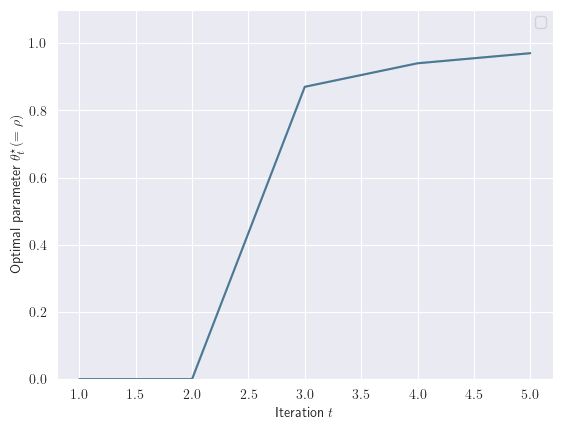

In [4]:
for idx in list_idx_ar:
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][3][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][3].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][3][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel(r'Optimal parameter $\theta_t^{\star} (=\rho)$')
plt.xlabel(r"Iteration $t$")
plt.ylim(0, 1.1)
plt.legend()
plt.savefig(DIR+"AR_optimal_parameter.png")

/tmp/ipykernel_3684/2106261455.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


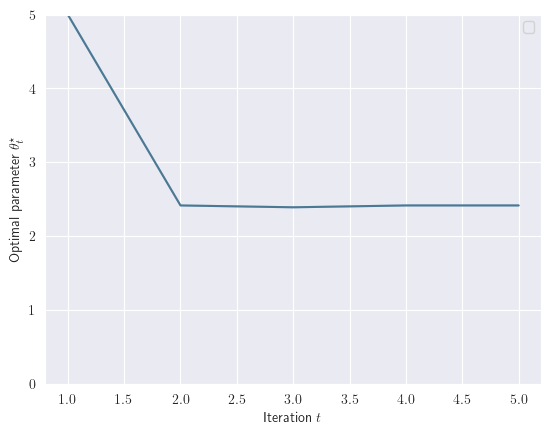

In [5]:
for idx in list_idx_rwmh:
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][3][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][3].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][3][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel(r'Optimal parameter $\theta_t^{\star}$')
plt.xlabel(r"Iteration $t$")
plt.ylim(0, 5)
plt.legend()
plt.savefig(DIR+"RW_optimal_parameter.png")

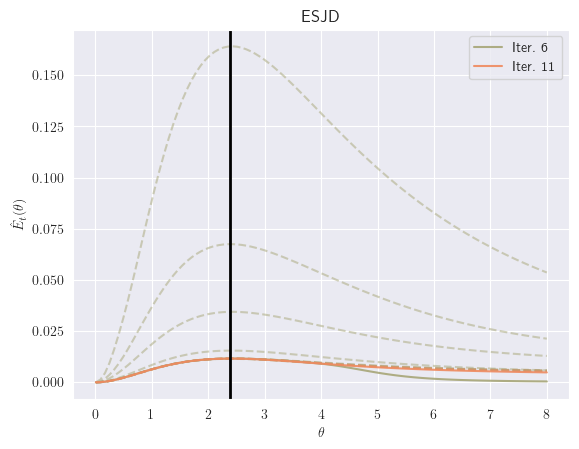

In [13]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 1
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
    plt.plot(GRID_ESJD, criteria_function[j], label=f"Iter. {str(j+1)}" if j%5==0 else None, alpha=0.9 if j%5==0 else 0.5, color=color_set[j//10], linestyle="solid" if j%5==0 else "--")
plt.axvline(x=2.38, ymin=0, ymax = 1, linewidth=2, color='k')
plt.legend()
plt.title("ESJD")
plt.ylabel(r"$\hat{E}_t(\theta)$")
plt.xlabel(r'$\theta$')
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function.png")

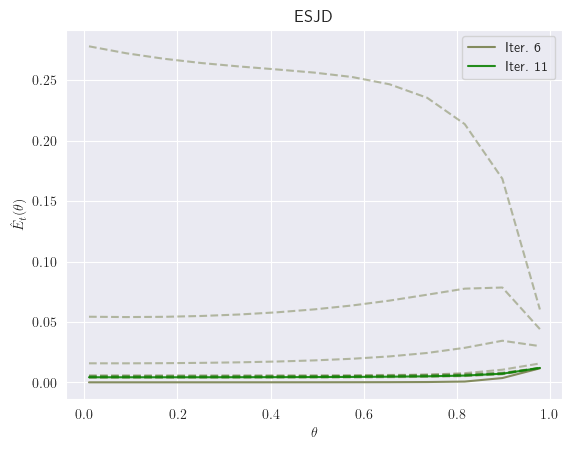

In [12]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 0
for j in range(1, PKLs[idx]['res'][5].shape[1]):
    criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
    plt.plot(GRID_ESJD, criteria_function[j], label=f"Iter. {str(j+1)}" if j%5==0 else None, alpha=0.9 if j%5==0 else 0.5, color=color_set[j//10], linestyle="solid" if j%5==0 else "--")
plt.legend()
plt.title("ESJD")
plt.ylabel(r"$\hat{E}_t(\theta)$")
plt.xlabel(r'$\theta$')
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function.png")